#Import and Stuff

In [387]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import BernoulliNB, MultinomialNB, ComplementNB, CategoricalNB
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

from sklearn.metrics import silhouette_samples, silhouette_score

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score

from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, SVMSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, NearMiss, TomekLinks
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer
import matplotlib.cm as cm
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif


In [388]:
def check_outlier(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)

    # Menghitung RUB dan RLB.
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5*IQR
    upper_limit = Q3 + 1.5*IQR

    # Menampilkan banyaknya outlier pada atribut.
    outliers = (df < lower_limit) | (df > upper_limit)
    print ("Outlier pada tiap atribut:")
    print(outliers.sum())

    return outliers

In [389]:
def evaluate_classifier_performance(prediction, y_test):
    print("Hasil Evaluasi berdasarkan classification report: \n\n%s\n" % (classification_report(y_test, prediction,zero_division=0)))
    print()
    print("Confusion Matrix")
    y_actual = pd.Series(np.array(y_test), name = "actual")
    y_pred = pd.Series(np.array(prediction), name = "prediction")
    df_confusion = pd.crosstab(y_actual, y_pred)
    display(df_confusion)
    print()

    print('Accuracy Average:', accuracy_score(y_test, prediction))
    print('F1 Macro Average:', f1_score(y_test, prediction, average='macro'))
    print('F1 Micro Average:', f1_score(y_test, prediction, average='micro'))
    print('Precision Macro Average:', precision_score(y_test, prediction, average='macro',zero_division=0))
    print('Precision Micro Average:', precision_score(y_test, prediction, average='micro',zero_division=0))
    print('Recall Macro Average:', recall_score(y_test, prediction, average='macro',zero_division=0))
    print('Recall Micro Average:', recall_score(y_test, prediction, average='micro',zero_division=0))
    print()

In [390]:
def evaluate_regressor_performance(y_pred, y_test):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

#Code Classification

##Pembacaan Dataset

In [391]:
train_csl = pd.read_csv('train_csl.csv')
train_csl.head(5)

,user_age_group,user_id,attempt_date,gender,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_title,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
0,25 to 34,1972,2017-12-22,male,712,15.8,382,Headquarters Business Park,54 kg and under,Night Ride,13.6,34.9,19.24,5103,5103,0,6977
1,25 to 34,239,2015-04-13,male,189,33.2,216,Oghor 2 SailsIsland,105 kg to 114 kg,Night Ride,21.5,43.2,23.47,3926,3926,0,3518
2,25 to 34,405,2018-02-07,male,264,23.7,593,Starbucks to Majid,75 to 84 kg,Evening Ride,26.7,92.9,38.23,5152,5152,0,415
3,25 to 34,318,2018-08-24,male,50,33.4,817,Al Fardoos to shellfish round about,75 to 84 kg,Afternoon Ride,31.4,54.4,65.77,7548,7548,1,1755
4,25 to 34,628,2020-03-06,female,19,21.3,284,Headquarters Business Park,54 kg and under,ثاني تمرين ١٠٠كم,19.9,43.2,96.53,17493,17493,0,7088


In [392]:
test_csl = pd.read_csv('test_csl_cla_x.csv')
test_csl.head(5)

,user_age_group,user_id,attempt_date,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_title,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
0,25 to 34,258,2018-03-12,112,28.9,487,Starbucks to Majid,75 to 84 kg,Mittagsradfahrt,25.5,45.7,50.39,7128,7128,0,265
1,35 to 44,731,2016-11-02,190,20.3,840,King Street side,85 to 95 kg,Evening Ride,19.9,37.8,35.00,6338,6338,0,2473
2,35 to 44,1144,2018-06-22,55,23.1,1180,Al Fardoos to shellfish round about,65 to 74 kg,Morning Ride,24.0,81.0,108.01,16202,16202,0,1835
3,35 to 44,830,2015-01-31,222,21.9,643,Starbucks to Majid,75 to 84 kg,Morning Ride,20.7,36.0,21.79,3787,3787,0,865
4,35 to 44,340,2014-10-21,278,22.7,266,Headquarters Business Park,65 to 74 kg,تمرين مع أحمد سعيد,23.8,43.9,31.05,4699,4699,0,7404


In [393]:
unique_users = train_csl['gender'].value_counts()
unique_users

,count
gender,
male,6039
female,253


In [394]:
print(train_csl.describe())

           user_id     smt_rank  smt_avg_spd  smt_finish_seconds  act_avg_spd  \
count  6292.000000  6292.000000   6292.00000         6292.000000  6292.000000   
mean    782.421964   172.515893     26.80925          531.276224    22.681024   
std     539.051866   173.487689      8.44806          431.974886     5.851547   
min       2.000000     1.000000      0.80000          112.000000     0.000000   
25%     335.000000    37.000000     21.30000          266.000000    18.700000   
50%     703.500000   108.000000     26.50000          439.000000    22.100000   
75%    1096.000000   267.000000     32.50000          651.000000    26.400000   
max    2254.000000   805.000000     87.30000         9224.000000    75.200000   

       act_max_spd  act_total_km  act_moving_seconds  act_total_seconds  \
count  6292.000000   6292.000000        6.292000e+03       6.292000e+03   
mean     44.757533     42.147134        1.252379e+04       1.252379e+04   
std      17.055338     27.010789        2.157

In [395]:
print(train_csl.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6292 entries, 0 to 6291
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_age_group        6292 non-null   object 
 1   user_id               6292 non-null   int64  
 2   attempt_date          6292 non-null   object 
 3   gender                6292 non-null   object 
 4   smt_rank              6292 non-null   int64  
 5   smt_avg_spd           6292 non-null   float64
 6   smt_finish_seconds    6292 non-null   int64  
 7   smt_name              6292 non-null   object 
 8   user_weight_category  5932 non-null   object 
 9   act_title             6292 non-null   object 
 10  act_avg_spd           6292 non-null   float64
 11  act_max_spd           6292 non-null   float64
 12  act_total_km          6292 non-null   float64
 13  act_moving_seconds    6292 non-null   int64  
 14  act_total_seconds     6292 non-null   int64  
 15  has_hr_data          

In [396]:
print(train_csl.head())

  user_age_group  user_id attempt_date  gender  smt_rank  smt_avg_spd  \
0       25 to 34     1972   2017-12-22    male       712         15.8   
1       25 to 34      239   2015-04-13    male       189         33.2   
2       25 to 34      405   2018-02-07    male       264         23.7   
3       25 to 34      318   2018-08-24    male        50         33.4   
4       25 to 34      628   2020-03-06  female        19         21.3   

   smt_finish_seconds                             smt_name  \
0                 382           Headquarters Business Park   
1                 216                  Oghor 2 SailsIsland   
2                 593                   Starbucks to Majid   
3                 817  Al Fardoos to shellfish round about   
4                 284           Headquarters Business Park   

  user_weight_category         act_title  act_avg_spd  act_max_spd  \
0      54 kg and under        Night Ride         13.6         34.9   
1     105 kg to 114 kg        Night Ride        

In [397]:
print("Jumlah duplikasi data : " + str(train_csl.duplicated().sum()))

Jumlah duplikasi data : 0


<Axes: >

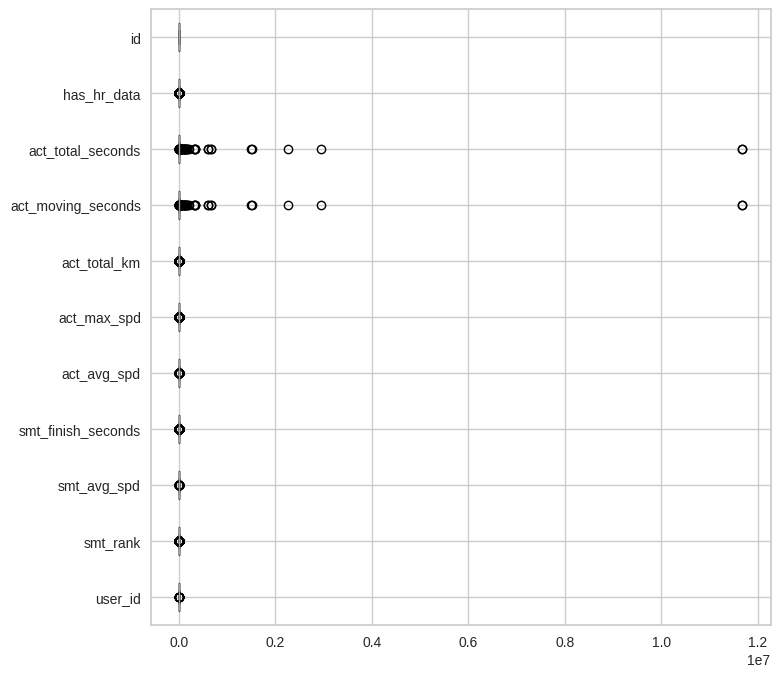

In [398]:
train_csl.boxplot(vert=False,figsize=(8,8))

In [399]:
outliers = dict(check_outlier(train_csl[[
    "id",
    "has_hr_data",
    "act_total_seconds",
    "act_moving_seconds",
    "act_total_km",
    "act_max_spd",
    "act_avg_spd",
    "smt_finish_seconds",
    "smt_avg_spd",
    "smt_rank",
    "user_id"
]]).sum())

Outlier pada tiap atribut:
id                       0
has_hr_data           1236
act_total_seconds      296
act_moving_seconds     296
act_total_km           308
act_max_spd            375
act_avg_spd             94
smt_finish_seconds     288
smt_avg_spd             53
smt_rank               163
user_id                 14
dtype: int64


##SNS Pairplot

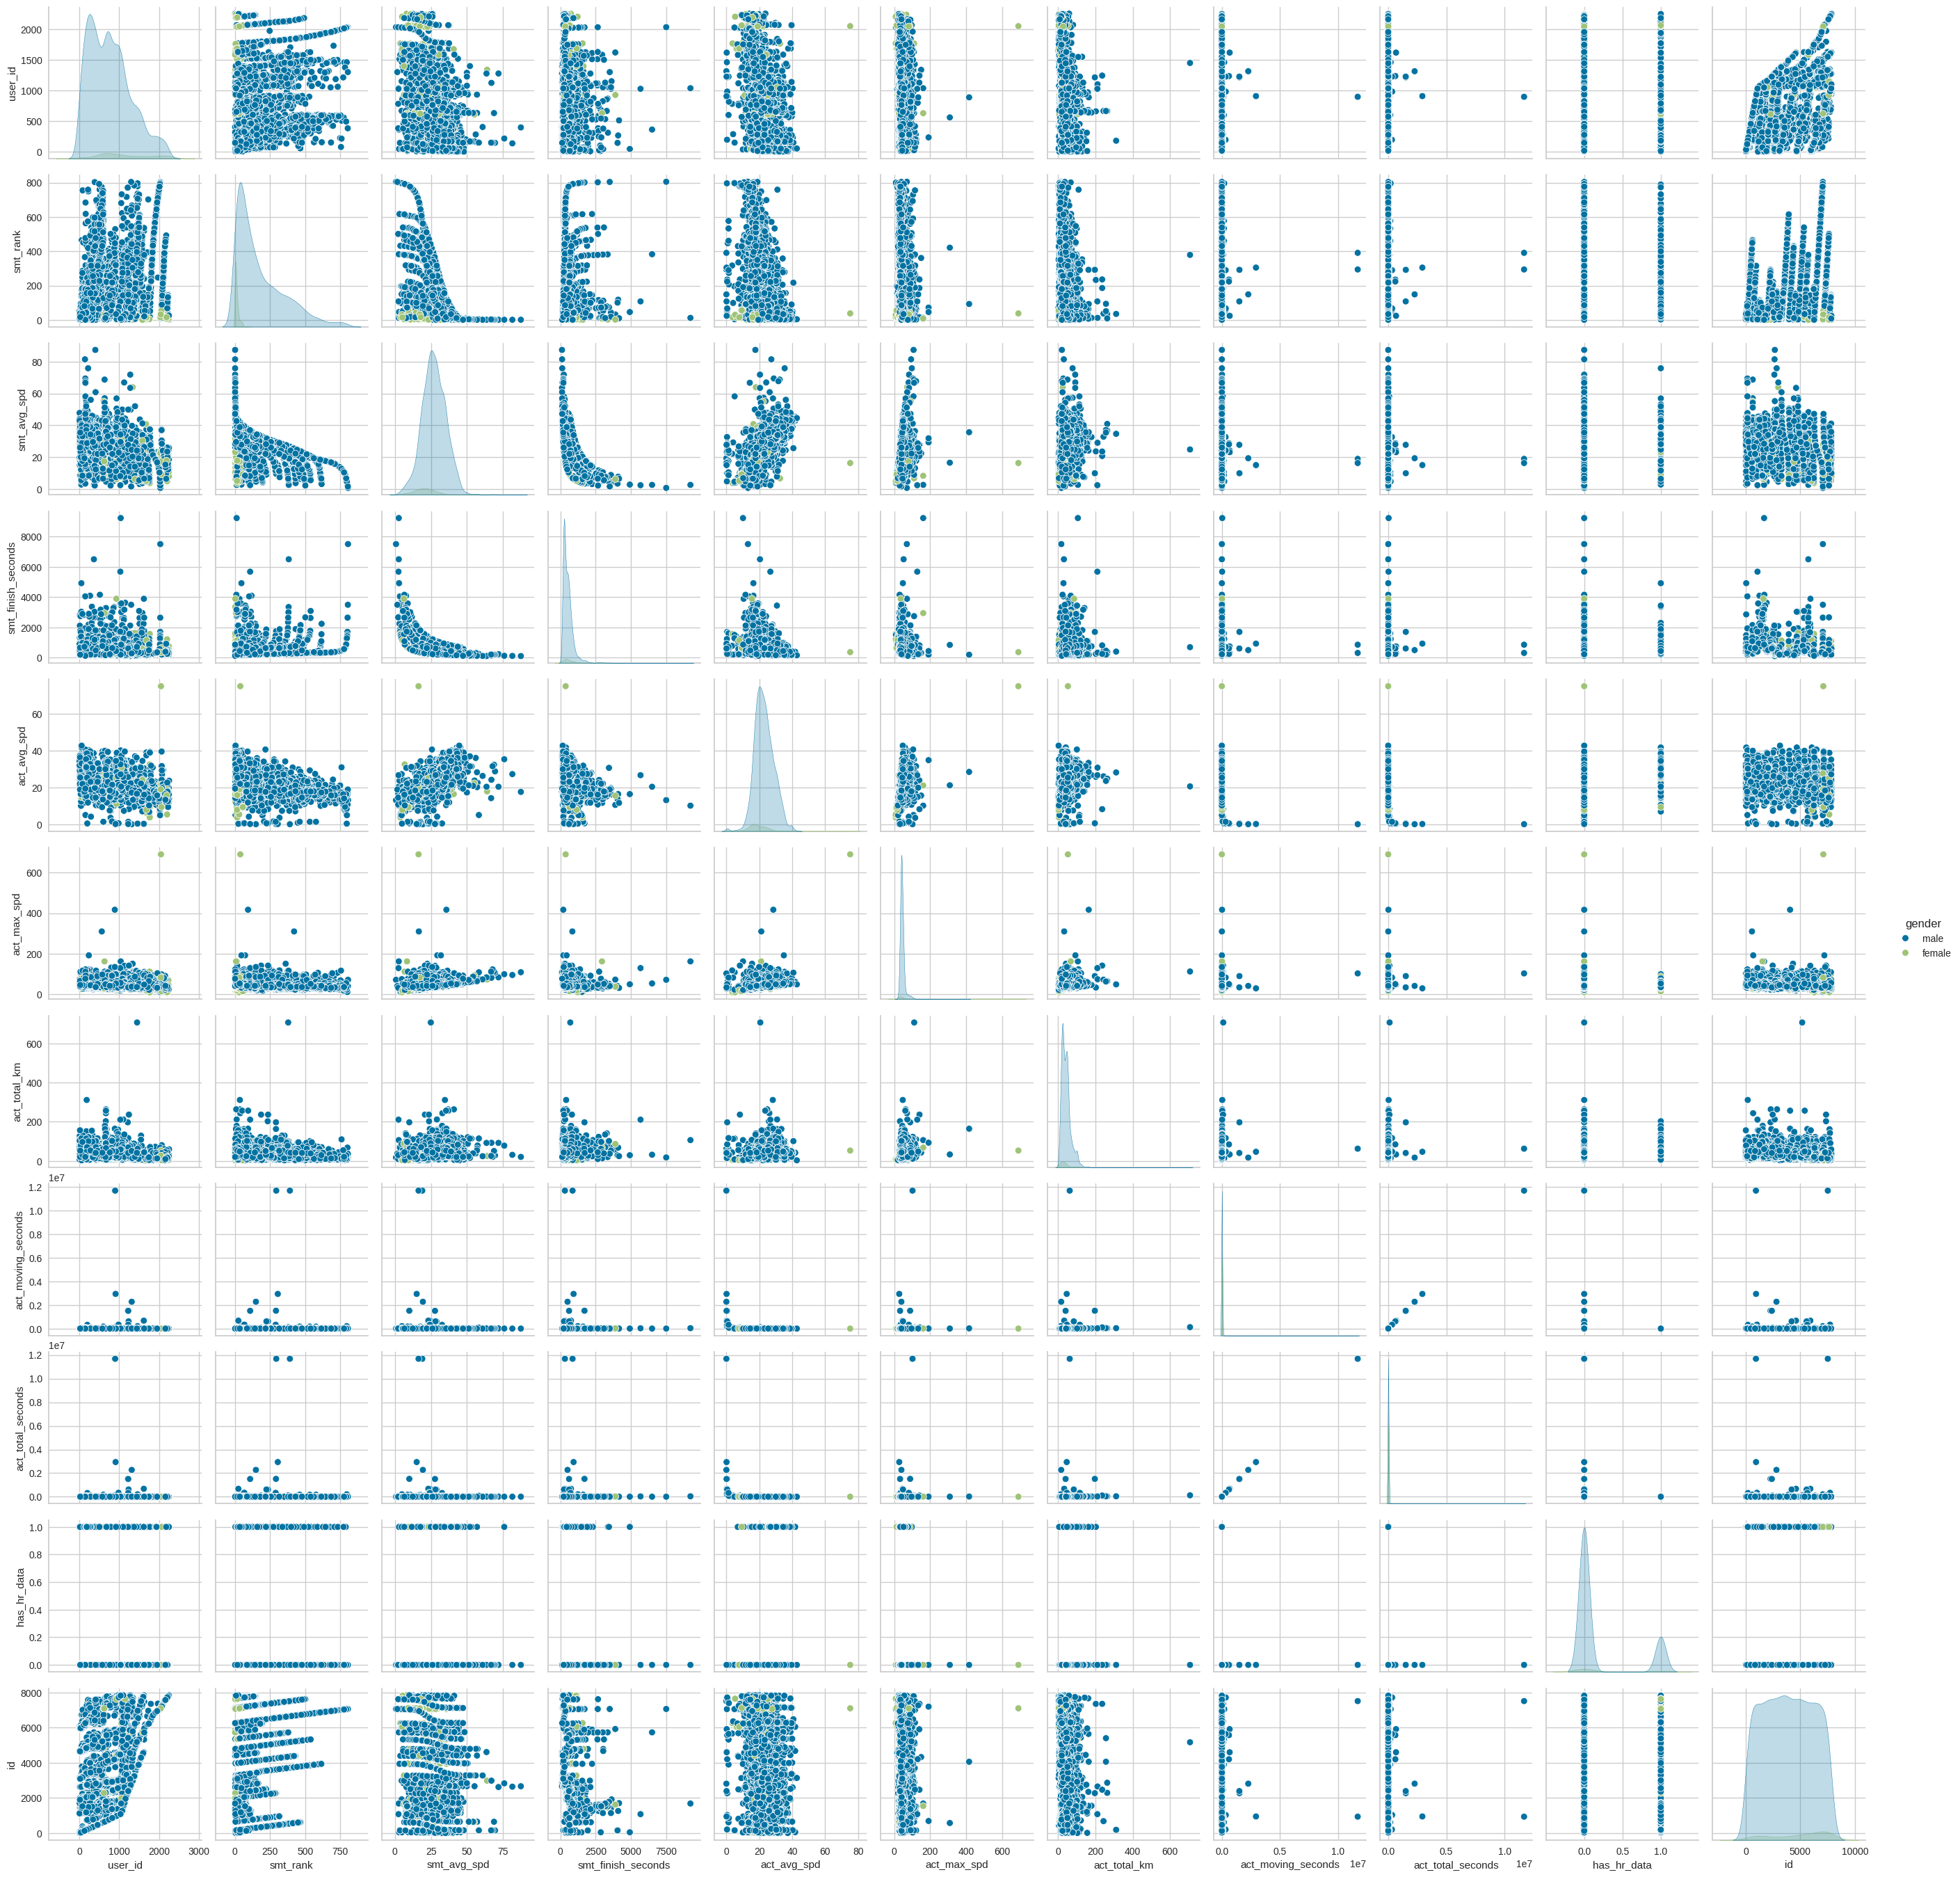

In [400]:
train_csl_copy = train_csl.copy()
sns.pairplot(train_csl_copy, hue ='gender')

##Preprocess

In [401]:
train_csl = train_csl.drop(columns=['user_id', 'attempt_date', 'smt_name', 'act_title'])

In [402]:
test_csl = test_csl.drop(columns=['user_id', 'attempt_date', 'smt_name', 'act_title'])

In [403]:
train_csl

,user_age_group,gender,smt_rank,smt_avg_spd,smt_finish_seconds,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
0,25 to 34,male,712,15.8,382,54 kg and under,13.6,34.9,19.24,5103,5103,0,6977
1,25 to 34,male,189,33.2,216,105 kg to 114 kg,21.5,43.2,23.47,3926,3926,0,3518
2,25 to 34,male,264,23.7,593,75 to 84 kg,26.7,92.9,38.23,5152,5152,0,415
3,25 to 34,male,50,33.4,817,75 to 84 kg,31.4,54.4,65.77,7548,7548,1,1755
4,25 to 34,female,19,21.3,284,54 kg and under,19.9,43.2,96.53,17493,17493,0,7088
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6287,25 to 34,male,431,22.3,778,NaN,17.9,96.5,41.93,8446,8446,0,5226
6288,35 to 44,male,34,38.9,446,85 to 95 kg,34.5,52.2,48.13,5026,5026,1,5390
6289,35 to 44,male,218,22.1,637,75 to 84 kg,17.6,40.7,50.64,10374,10374,0,860
6290,35 to 44,male,477,12.4,485,85 to 95 kg,14.5,34.9,40.93,10158,10158,0,7603


In [404]:
test_csl

,user_age_group,smt_rank,smt_avg_spd,smt_finish_seconds,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
0,25 to 34,112,28.9,487,75 to 84 kg,25.5,45.7,50.39,7128,7128,0,265
1,35 to 44,190,20.3,840,85 to 95 kg,19.9,37.8,35.00,6338,6338,0,2473
2,35 to 44,55,23.1,1180,65 to 74 kg,24.0,81.0,108.01,16202,16202,0,1835
3,35 to 44,222,21.9,643,75 to 84 kg,20.7,36.0,21.79,3787,3787,0,865
4,35 to 44,278,22.7,266,65 to 74 kg,23.8,43.9,31.05,4699,4699,0,7404
...,...,...,...,...,...,...,...,...,...,...,...,...
781,45 to 54,85,19.3,728,65 to 74 kg,24.4,35.6,74.71,11025,11025,0,1055
782,25 to 34,43,41.2,174,54 kg and under,25.5,51.1,63.13,8925,8925,0,3322
783,35 to 44,297,23.8,730,105 kg to 114 kg,19.3,32.4,21.32,3971,3971,0,5652
784,19 and under,56,8.1,883,65 to 74 kg,18.1,41.8,17.95,3562,3562,0,3131


In [405]:
unique_age = train_csl['user_age_group'].value_counts()
unique_age

,count
user_age_group,
25 to 34,2708
35 to 44,1866
45 to 54,667
20 to 24,568
19 and under,297
55 to 64,152
65 to 69,16
75+,15
70 to 74,3


In [406]:
unique_weight = train_csl['user_weight_category'].value_counts()
unique_weight

,count
user_weight_category,
54 kg and under,1972
75 to 84 kg,1162
65 to 74 kg,842
85 to 95 kg,835
95 kg to 104 kg,425
55 to 64 kg,279
105 kg to 114 kg,241
115 kg and over,176


In [407]:
# Mapping manual untuk user_age_group
age_group_mapping = {
    "19 and under": 0,
    "20 to 24": 1,
    "25 to 34": 2,
    "35 to 44": 3,
    "45 to 54": 4,
    "55 to 64": 5,
    "65 to 69": 6,
    "70 to 74": 7,
    "75+": 8
}

# Mapping manual untuk user_weight_category
weight_category_mapping = {
    "54 kg and under": 0,
    "55 to 64 kg": 1,
    "65 to 74 kg": 2,
    "75 to 84 kg": 3,
    "85 to 95 kg": 4,
    "95 kg to 104 kg": 5,
    "105 kg to 114 kg": 6,
    "115 kg and over": 7
}

In [408]:
# Terapkan mapping manual
train_csl['user_age_group'] = train_csl['user_age_group'].map(age_group_mapping)
train_csl['user_weight_category'] = train_csl['user_weight_category'].map(weight_category_mapping)

In [409]:
# Terapkan mapping manual
test_csl['user_age_group'] = test_csl['user_age_group'].map(age_group_mapping)
test_csl['user_weight_category'] = test_csl['user_weight_category'].map(weight_category_mapping)

In [410]:
train_csl.head()

,user_age_group,gender,smt_rank,smt_avg_spd,smt_finish_seconds,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
0,2,male,712,15.8,382,0.0,13.6,34.9,19.24,5103,5103,0,6977
1,2,male,189,33.2,216,6.0,21.5,43.2,23.47,3926,3926,0,3518
2,2,male,264,23.7,593,3.0,26.7,92.9,38.23,5152,5152,0,415
3,2,male,50,33.4,817,3.0,31.4,54.4,65.77,7548,7548,1,1755
4,2,female,19,21.3,284,0.0,19.9,43.2,96.53,17493,17493,0,7088


In [411]:
median_value = train_csl['user_weight_category'].median()

# Mengisi nilai kosong dengan median
train_csl['user_weight_category'] = train_csl['user_weight_category'].fillna(median_value)

# Mengecek ulang jumlah nilai kosong
print("Jumlah nilai kosong setelah imputasi:")
print(train_csl['user_weight_category'].isnull().sum())

Jumlah nilai kosong setelah imputasi:
0


In [412]:
median_value = test_csl['user_weight_category'].median()

# Mengisi nilai kosong dengan median
test_csl['user_weight_category'] = test_csl['user_weight_category'].fillna(median_value)

# Mengecek ulang jumlah nilai kosong
print("Jumlah nilai kosong setelah imputasi:")
print(test_csl['user_weight_category'].isnull().sum())

Jumlah nilai kosong setelah imputasi:
0


In [413]:
print(train_csl.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6292 entries, 0 to 6291
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_age_group        6292 non-null   int64  
 1   gender                6292 non-null   object 
 2   smt_rank              6292 non-null   int64  
 3   smt_avg_spd           6292 non-null   float64
 4   smt_finish_seconds    6292 non-null   int64  
 5   user_weight_category  6292 non-null   float64
 6   act_avg_spd           6292 non-null   float64
 7   act_max_spd           6292 non-null   float64
 8   act_total_km          6292 non-null   float64
 9   act_moving_seconds    6292 non-null   int64  
 10  act_total_seconds     6292 non-null   int64  
 11  has_hr_data           6292 non-null   int64  
 12  id                    6292 non-null   int64  
dtypes: float64(5), int64(7), object(1)
memory usage: 639.2+ KB
None


In [414]:
outliers = check_outlier(train_csl[[
    "has_hr_data",
    "act_total_seconds",
    "act_moving_seconds",
    "act_total_km",
    "act_max_spd",
    "act_avg_spd",
    "smt_finish_seconds",
    "smt_avg_spd",
    "smt_rank",
]])
train_csl_cleaned = train_csl[~outliers.any(axis=1)]

# Menampilkan hasil
print("Jumlah data sebelum menghapus outlier:", train_csl.shape[0])
print("Jumlah data setelah menghapus outlier:", train_csl_cleaned.shape[0])

Outlier pada tiap atribut:
has_hr_data           1236
act_total_seconds      296
act_moving_seconds     296
act_total_km           308
act_max_spd            375
act_avg_spd             94
smt_finish_seconds     288
smt_avg_spd             53
smt_rank               163
dtype: int64
Jumlah data sebelum menghapus outlier: 6292
Jumlah data setelah menghapus outlier: 4104


In [415]:
outliers = check_outlier(train_csl_cleaned[[
    "has_hr_data",
    "act_total_seconds",
    "act_moving_seconds",
    "act_total_km",
    "act_max_spd",
    "act_avg_spd",
    "smt_finish_seconds",
    "smt_avg_spd",
    "smt_rank",
]])

unique_users = train_csl_cleaned['gender'].value_counts()
unique_users

Outlier pada tiap atribut:
has_hr_data            0
act_total_seconds     41
act_moving_seconds    41
act_total_km          28
act_max_spd           55
act_avg_spd           58
smt_finish_seconds    36
smt_avg_spd           18
smt_rank               0
dtype: int64


,count
gender,
male,3950
female,154


<Axes: >

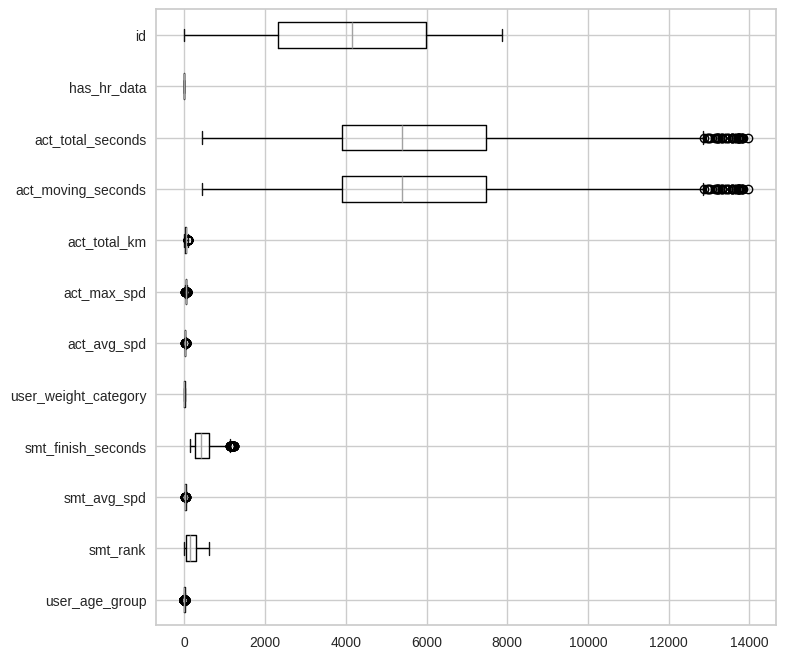

In [416]:
train_csl_cleaned.boxplot(vert=False,figsize=(8,8))

##Spliting Train Test

In [417]:
X = train_csl.drop('gender', axis=1)
y = train_csl['gender']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [418]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

test_csl_scaled = scaler.fit_transform(test_csl)

##Finding Model

In [419]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Definisikan pipeline dengan model dan sampling
pipeline = ImbPipeline([
    ('sampling', SMOTE()),  # Sampling placeholder, akan diganti oleh GridSearchCV
    ('model', RandomForestClassifier(random_state=42))  # Model placeholder, akan diganti oleh GridSearchCV
])

# Parameter yang ingin dicoba
param_grid = {
    'sampling': [SMOTE(), BorderlineSMOTE(), ADASYN(),
                 NearMiss(), NearMiss(version=2), NearMiss(version=3), TomekLinks()],
    'model': [
        DecisionTreeClassifier(random_state=42),
        RandomForestClassifier(random_state=42),
        KNeighborsClassifier(),
        MLPClassifier(hidden_layer_sizes=(50, 40, 20), random_state=42, max_iter=1000),
        BernoulliNB(),
        MultinomialNB(),
        ComplementNB(),
        CategoricalNB()
    ],
}

# GridSearchCV untuk memilih kombinasi terbaik antara sampling dan model
print("Tuning hyper-parameters model")
grid_search = GridSearchCV(pipeline, param_grid, cv=skf, scoring='f1_macro', verbose=3)

# Fitting grid search pada data
grid_search.fit(X_train_scaled, y_train)

Tuning hyper-parameters model
Fitting 5 folds for each of 56 candidates, totalling 280 fits
[CV 1/5] END model=DecisionTreeClassifier(random_state=42), sampling=SMOTE();, score=0.947 total time=   0.2s
[CV 2/5] END model=DecisionTreeClassifier(random_state=42), sampling=SMOTE();, score=0.925 total time=   0.2s
[CV 3/5] END model=DecisionTreeClassifier(random_state=42), sampling=SMOTE();, score=0.937 total time=   0.1s
[CV 4/5] END model=DecisionTreeClassifier(random_state=42), sampling=SMOTE();, score=0.942 total time=   0.1s
[CV 5/5] END model=DecisionTreeClassifier(random_state=42), sampling=SMOTE();, score=0.938 total time=   0.1s
[CV 1/5] END model=DecisionTreeClassifier(random_state=42), sampling=BorderlineSMOTE();, score=0.948 total time=   0.2s
[CV 2/5] END model=DecisionTreeClassifier(random_state=42), sampling=BorderlineSMOTE();, score=0.939 total time=   0.1s
[CV 3/5] END model=DecisionTreeClassifier(random_state=42), sampling=BorderlineSMOTE();, score=0.925 total time=   0.1

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/_response.py", line 214, in _get_response_values
    y_pred = prediction_method

[CV 5/5] END model=CategoricalNB(), sampling=SMOTE();, score=nan total time=   0.0s
[CV 1/5] END model=CategoricalNB(), sampling=BorderlineSMOTE();, score=nan total time=   0.1s
[CV 2/5] END model=CategoricalNB(), sampling=BorderlineSMOTE();, score=0.464 total time=   0.1s
[CV 3/5] END model=CategoricalNB(), sampling=BorderlineSMOTE();, score=0.480 total time=   0.1s


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/_response.py", line 214, in _get_response_values
    y_pred = prediction_method

[CV 4/5] END model=CategoricalNB(), sampling=BorderlineSMOTE();, score=nan total time=   0.1s
[CV 5/5] END model=CategoricalNB(), sampling=BorderlineSMOTE();, score=nan total time=   0.1s
[CV 1/5] END model=CategoricalNB(), sampling=ADASYN();, score=nan total time=   0.1s
[CV 2/5] END model=CategoricalNB(), sampling=ADASYN();, score=0.464 total time=   0.1s


...

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/_response.py", line 214, in _get_response_values
    y_pred = prediction_method

[CV 2/5] END model=CategoricalNB(), sampling=TomekLinks();, score=0.489 total time=   0.2s
[CV 3/5] END model=CategoricalNB(), sampling=TomekLinks();, score=0.489 total time=   0.2s


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/_response.py", line 214, in _get_response_values
    y_pred = prediction_method

[CV 4/5] END model=CategoricalNB(), sampling=TomekLinks();, score=nan total time=   0.2s
[CV 5/5] END model=CategoricalNB(), sampling=TomekLinks();, score=nan total time=   0.2s


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sampling', SMOTE()),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'model': [DecisionTreeClassifier(random_state=42),
                                   RandomForestClassifier(random_state=42),
                                   KNeighborsClassifier(),
                                   MLPClassifier(hidden_layer_sizes=(50, 40,
                                                                     20),
                                                 max_iter=1000,
                                                 random_state=42),
                                   BernoulliNB(), MultinomialNB(),
                                   ComplementNB(), CategoricalNB()],
                         'sampling': [SMOTE(), BorderlineSMOTE(), ADASYN(),
                                      NearMiss(), NearMiss(version=2),
                                      NearMiss(version=3), TomekLinks()]},
             scoring='f1_macro', verbose=3)

In [420]:
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Model: ", best_model)
print("Best Parameters: ", best_params)
print("Best F1 Macro Score: ", best_score)

Best Model:  Pipeline(steps=[('sampling', BorderlineSMOTE()),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(50, 40, 20), max_iter=1000,
                               random_state=42))])
Best Parameters:  {'model': MLPClassifier(hidden_layer_sizes=(50, 40, 20), max_iter=1000, random_state=42), 'sampling': BorderlineSMOTE()}
Best F1 Macro Score:  0.9751118714453385


##Select Model

In [421]:
best_pipeline = ImbPipeline([
    ('sampling', BorderlineSMOTE()),
    ('model', MLPClassifier(hidden_layer_sizes=(50, 40, 20), max_iter=1000, random_state=42))
])

In [422]:
best_pipeline.fit(X_train_scaled, y_train)

Pipeline(steps=[('sampling', BorderlineSMOTE()),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(50, 40, 20), max_iter=1000,
                               random_state=42))])

In [423]:
# Menghitung dan menampilkan hasil prediksi serta skor f1 macro
y_pred = best_pipeline.predict(X_test_scaled)
f1_macro_score = f1_score(y_test, y_pred, average='macro')

print(f"Best F1 Macro Score on Test Data: {f1_macro_score}")

Best F1 Macro Score on Test Data: 0.9759218176254589


In [424]:
y_pred = best_pipeline.predict(X_test_scaled)

print("=====================================================")
print("Model - MLP")
evaluate_classifier_performance(y_pred, y_test)

Model - MLP
Hasil Evaluasi berdasarkan classification report: 

              precision    recall  f1-score   support

      female       0.98      0.93      0.95        44
        male       1.00      1.00      1.00      1215

    accuracy                           1.00      1259
   macro avg       0.99      0.97      0.98      1259
weighted avg       1.00      1.00      1.00      1259



Confusion Matrix


prediction,female,male
actual,,
female,41,3
male,1,1214



Accuracy Average: 0.9968228752978554
F1 Macro Average: 0.9759218176254589
F1 Micro Average: 0.9968228752978554
Precision Macro Average: 0.9868626990648355
Precision Micro Average: 0.9968228752978554
Recall Macro Average: 0.965497568275346
Recall Micro Average: 0.9968228752978554



##Pada Dataset Test

In [425]:
y_pred = best_pipeline.predict(test_csl_scaled)

In [426]:
y_pred

array(['male', 'male', 'male', 'male', 'male', 'male', 'male', 'male',
       'male', 'male', 'male', 'male', 'male', 'male', 'male', 'male',
       'male', 'male', 'male', 'male', 'male', 'male', 'male', 'male',
       'male', 'male', 'male', 'male', 'male', 'male', 'male', 'male',
       'male', 'male', 'male', 'male', 'male', 'male', 'male', 'male',
       'male', 'male', 'male', 'male', 'male', 'male', 'male', 'male',
       'male', 'male', 'male', 'male', 'male', 'male', 'male', 'male',
       'male', 'male', 'male', 'male', 'male', 'male', 'male', 'male',
       'male', 'male', 'male', 'male', 'male', 'male', 'male', 'male',
       'male', 'male', 'male', 'male', 'male', 'male', 'male', 'male',
       'male', 'male', 'male', 'male', 'male', 'male', 'male', 'male',
       'male', 'male', 'male', 'male', 'male', 'male', 'male', 'male',
       'male', 'male', 'male', 'male', 'male', 'male', 'male', 'male',
       'female', 'male', 'male', 'male', 'male', 'male', 'male', 'male',
    

In [427]:
df_results = pd.DataFrame({
    'id': test_csl['id'],
    'gender': y_pred
})

kaggle_cla_map = {
    'female' :1,
    'male' :2
}

df_results.loc[:, 'gender'] = df_results['gender'].map(kaggle_cla_map)

In [428]:
df_results

,id,gender
0,265,2
1,2473,2
2,1835,2
3,865,2
4,7404,2
...,...,...
781,1055,2
782,3322,2
783,5652,2
784,3131,2


In [429]:
# Simpan DataFrame ke file CSV
df_results.to_csv('classification_csl_admission_result_bingchilling_alle.csv', index=False)

print("Predictions saved to predictions.csv")

Predictions saved to predictions.csv


#Code Regression

##Pembacaan Dataset

In [430]:
train_csl_regression = pd.read_csv('train_csl.csv')
train_csl_regression.head(5)

,user_age_group,user_id,attempt_date,gender,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_title,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
0,25 to 34,1972,2017-12-22,male,712,15.8,382,Headquarters Business Park,54 kg and under,Night Ride,13.6,34.9,19.24,5103,5103,0,6977
1,25 to 34,239,2015-04-13,male,189,33.2,216,Oghor 2 SailsIsland,105 kg to 114 kg,Night Ride,21.5,43.2,23.47,3926,3926,0,3518
2,25 to 34,405,2018-02-07,male,264,23.7,593,Starbucks to Majid,75 to 84 kg,Evening Ride,26.7,92.9,38.23,5152,5152,0,415
3,25 to 34,318,2018-08-24,male,50,33.4,817,Al Fardoos to shellfish round about,75 to 84 kg,Afternoon Ride,31.4,54.4,65.77,7548,7548,1,1755
4,25 to 34,628,2020-03-06,female,19,21.3,284,Headquarters Business Park,54 kg and under,ثاني تمرين ١٠٠كم,19.9,43.2,96.53,17493,17493,0,7088


In [431]:
test_csl_regression = pd.read_csv('test_csl_reg_x.csv')
test_csl_regression.head(5)

,user_age_group,user_id,attempt_date,smt_rank,smt_avg_spd,smt_name,user_weight_category,act_title,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id,gender
0,25 to 34,564,2018-07-15,33,36.9,PRINCE SULTAN - ASSALAM TO FATIMA,65 to 74 kg,Night Ride,34.6,50.8,41.61,4326,4326,0,2699,male
1,25 to 34,323,2018-01-03,181,26.2,Starbucks to Majid,75 to 84 kg,احلى تمرين مع دراج جدة two hearts person bikin...,25.4,40.3,45.37,6427,6427,0,332,male
2,25 to 34,149,2019-07-19,3,56.0,Oghor 2 SailsIsland,54 kg and under,Afternoon Ride,22.6,85.3,78.45,12507,12507,0,3282,male
3,45 to 54,1027,2018-06-22,142,11.1,North Corniche,75 to 84 kg,Morning Ride,12.1,16.9,21.01,6254,6254,0,5891,male
4,35 to 44,823,2018-08-29,216,22.2,Starbucks to Majid,85 to 95 kg,تمرين جميل مع دراج جدة red heart,21.9,45.7,57.15,9398,9398,0,858,male


##PreProcess

In [432]:
train_csl_regression = train_csl_regression.drop(columns=['user_id', 'attempt_date', 'smt_name', 'act_title'])

In [433]:
test_csl_regression = test_csl_regression.drop(columns=['user_id', 'attempt_date', 'smt_name', 'act_title'])

In [434]:
# Mapping manual untuk user_age_group
age_group_mapping = {
    "19 and under": 0,
    "20 to 24": 1,
    "25 to 34": 2,
    "35 to 44": 3,
    "45 to 54": 4,
    "55 to 64": 5,
    "65 to 69": 6,
    "70 to 74": 7,
    "75+": 8
}

# Mapping manual untuk user_weight_category
weight_category_mapping = {
    "54 kg and under": 0,
    "55 to 64 kg": 1,
    "65 to 74 kg": 2,
    "75 to 84 kg": 3,
    "85 to 95 kg": 4,
    "95 kg to 104 kg": 5,
    "105 kg to 114 kg": 6,
    "115 kg and over": 7
}

In [435]:
# Terapkan mapping manual
train_csl_regression['user_age_group'] = train_csl_regression['user_age_group'].map(age_group_mapping)
train_csl_regression['user_weight_category'] = train_csl_regression['user_weight_category'].map(weight_category_mapping)

In [436]:
# Terapkan mapping manual
test_csl_regression['user_age_group'] = test_csl_regression['user_age_group'].map(age_group_mapping)
test_csl_regression['user_weight_category'] = test_csl_regression['user_weight_category'].map(weight_category_mapping)

In [437]:
median_value = train_csl_regression['user_weight_category'].median()

# Mengisi nilai kosong dengan median
train_csl_regression['user_weight_category'] = train_csl_regression['user_weight_category'].fillna(median_value)

# Mengecek ulang jumlah nilai kosong
print("Jumlah nilai kosong setelah imputasi:")
print(train_csl_regression['user_weight_category'].isnull().sum())

Jumlah nilai kosong setelah imputasi:
0


In [438]:
encoder = OneHotEncoder()

df_encoded_train_regression = pd.get_dummies(train_csl_regression, columns=['gender'], prefix='gender', drop_first=True)

df_encoded_test_regression = pd.get_dummies(test_csl_regression, columns=['gender'], prefix='gender', drop_first=True)

In [439]:
df_encoded_train_regression.head(5)

,user_age_group,smt_rank,smt_avg_spd,smt_finish_seconds,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id,gender_male
0,2,712,15.8,382,0.0,13.6,34.9,19.24,5103,5103,0,6977,True
1,2,189,33.2,216,6.0,21.5,43.2,23.47,3926,3926,0,3518,True
2,2,264,23.7,593,3.0,26.7,92.9,38.23,5152,5152,0,415,True
3,2,50,33.4,817,3.0,31.4,54.4,65.77,7548,7548,1,1755,True
4,2,19,21.3,284,0.0,19.9,43.2,96.53,17493,17493,0,7088,False


In [440]:
df_encoded_test_regression.head(5)

,user_age_group,smt_rank,smt_avg_spd,user_weight_category,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id,gender_male
0,2,33,36.9,2.0,34.6,50.8,41.61,4326,4326,0,2699,True
1,2,181,26.2,3.0,25.4,40.3,45.37,6427,6427,0,332,True
2,2,3,56.0,0.0,22.6,85.3,78.45,12507,12507,0,3282,True
3,4,142,11.1,3.0,12.1,16.9,21.01,6254,6254,0,5891,True
4,3,216,22.2,4.0,21.9,45.7,57.15,9398,9398,0,858,True


##Splitting Train

In [441]:
X = df_encoded_train_regression.drop('smt_finish_seconds', axis=1)
y = df_encoded_train_regression['smt_finish_seconds']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [442]:
# Inisialisasi StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_real_test_scaled = scaler.fit_transform(df_encoded_test_regression)

##Finding Model

In [443]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

# Model dan parameter
models = {
    'Linear': LinearRegression(),
    'Lasso': Lasso(),
    'Ridge': Ridge(),
    'ElasticNet': ElasticNet(),
    'RandomForest': RandomForestRegressor(),
    'DecisionTree': DecisionTreeRegressor(),
    'KNN': KNeighborsRegressor()
}

param_grids = {
    'Linear': {},  # Tidak ada parameter untuk Linear Regression
    'Lasso': {'alpha': [0.0001, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]},
    'Ridge': {'alpha': [0.0001, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]},
    'ElasticNet': {'alpha': [0.0001, 0.1, 1.0, 2.0, 5.0, 10.0], 'l1_ratio': [0.2, 0.5, 0.8]},
    'RandomForest': {'n_estimators': [10, 50, 100], 'max_depth': [5, 10, None]},
    'DecisionTree': {'max_depth': [5, 10, 20, None],
                     'min_samples_split': [2, 5, 10],
                     'min_samples_leaf': [1, 2, 5]},
    'KNN': {'n_neighbors': [3, 5, 10, 20],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']}
}

# Grid Search untuk masing-masing model
results = {}
for model_name, model in models.items():
    grid = GridSearchCV(model, param_grids[model_name], scoring='r2', cv=5)
    grid.fit(X_train_scaled, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    results[model_name] = {
        'Best Params': grid.best_params_,
        'Best R2': r2
    }

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.900e+08, tolerance: 8.151e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.054e+08, tolerance: 8.418e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.105e+08, tolerance: 8.350e

In [444]:
# Menampilkan hasil
print("Hasil Grid Search untuk R² Terbaik:")
for model_name, result in results.items():
    print(f"{model_name}:")
    print(f"  Best Params: {result['Best Params']}")
    print(f"  R² Score: {result['Best R2']:.4f}")

# Model dengan R² terbaik
best_model_name = max(results, key=lambda x: results[x]['Best R2'])
print(f"\nModel terbaik adalah {best_model_name} dengan R² {results[best_model_name]['Best R2']:.4f}.")

Hasil Grid Search untuk R² Terbaik:
Linear:
  Best Params: {}
  R² Score: 0.4317
Lasso:
  Best Params: {'alpha': 2.0}
  R² Score: 0.4341
Ridge:
  Best Params: {'alpha': 10.0}
  R² Score: 0.4324
ElasticNet:
  Best Params: {'alpha': 0.1, 'l1_ratio': 0.8}
  R² Score: 0.4373
RandomForest:
  Best Params: {'max_depth': None, 'n_estimators': 50}
  R² Score: 0.9010
DecisionTree:
  Best Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10}
  R² Score: 0.8250
KNN:
  Best Params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
  R² Score: 0.7784

Model terbaik adalah RandomForest dengan R² 0.9010.


##Select Model

In [445]:
best_params = {'max_depth': None, 'n_estimators': 100}
best_model = RandomForestRegressor(**best_params, random_state=42)

In [446]:
# Melatih model dengan data training
best_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [447]:
# Evaluasi model pada data test
y_pred = best_model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)

print(f"RandomForest Model - R² Score: {r2:.4f}")

RandomForest Model - R² Score: 0.9059


In [448]:
print("=====================================================")
print("Model - Random Forest('max_depth': None, 'n_estimators': 100)")
evaluate_regressor_performance(y_pred, y_test)
print()

Model - Random Forest('max_depth': None, 'n_estimators': 100)
Mean Absolute Error (MAE): 15.8262
Mean Squared Error (MSE): 12609.3856
Root Mean Squared Error (RMSE): 112.2915
R² Score: 0.9059



##Pada Dataset Test

In [449]:
y_pred = best_model.predict(X_real_test_scaled)

In [450]:
df_results = pd.DataFrame({
    'id': df_encoded_test_regression['id'],  # Asumsikan kolom ID masih ada
    'smt_finish_seconds': y_pred  # Hasil prediksi
})

df_results.to_csv('regression_csl_admission_result_bingchilling_alle.csv', index=False)

#Code Clustering

##Pembacaan Dataset

In [451]:
train_csl_clustering = pd.read_csv('train_csl.csv')
train_csl_clustering.head(5)

,user_age_group,user_id,attempt_date,gender,smt_rank,smt_avg_spd,smt_finish_seconds,smt_name,user_weight_category,act_title,act_avg_spd,act_max_spd,act_total_km,act_moving_seconds,act_total_seconds,has_hr_data,id
0,25 to 34,1972,2017-12-22,male,712,15.8,382,Headquarters Business Park,54 kg and under,Night Ride,13.6,34.9,19.24,5103,5103,0,6977
1,25 to 34,239,2015-04-13,male,189,33.2,216,Oghor 2 SailsIsland,105 kg to 114 kg,Night Ride,21.5,43.2,23.47,3926,3926,0,3518
2,25 to 34,405,2018-02-07,male,264,23.7,593,Starbucks to Majid,75 to 84 kg,Evening Ride,26.7,92.9,38.23,5152,5152,0,415
3,25 to 34,318,2018-08-24,male,50,33.4,817,Al Fardoos to shellfish round about,75 to 84 kg,Afternoon Ride,31.4,54.4,65.77,7548,7548,1,1755
4,25 to 34,628,2020-03-06,female,19,21.3,284,Headquarters Business Park,54 kg and under,ثاني تمرين ١٠٠كم,19.9,43.2,96.53,17493,17493,0,7088


##PreProcess

In [452]:
# Mapping manual untuk user_age_group
age_group_mapping = {
    "19 and under": 0,
    "20 to 24": 1,
    "25 to 34": 2,
    "35 to 44": 3,
    "45 to 54": 4,
    "55 to 64": 5,
    "65 to 69": 6,
    "70 to 74": 7,
    "75+": 8
}

# Mapping manual untuk user_weight_category
weight_category_mapping = {
    "54 kg and under": 0,
    "55 to 64 kg": 1,
    "65 to 74 kg": 2,
    "75 to 84 kg": 3,
    "85 to 95 kg": 4,
    "95 kg to 104 kg": 5,
    "105 kg to 114 kg": 6,
    "115 kg and over": 7
}

In [453]:
# Terapkan mapping manual
train_csl_clustering['user_age_group'] = train_csl_clustering['user_age_group'].map(age_group_mapping)
train_csl_clustering['user_weight_category'] = train_csl_clustering['user_weight_category'].map(weight_category_mapping)

In [454]:
median_value = train_csl_clustering['user_weight_category'].median()

# Mengisi nilai kosong dengan median
train_csl_clustering['user_weight_category'] = train_csl_clustering['user_weight_category'].fillna(median_value)

# Mengecek ulang jumlah nilai kosong
print("Jumlah nilai kosong setelah imputasi:")
print(train_csl_clustering['user_weight_category'].isnull().sum())

Jumlah nilai kosong setelah imputasi:
0


In [455]:
df_cluster = train_csl_clustering[['act_total_km', 'act_avg_spd', 'user_age_group']]
df_cluster

,act_total_km,act_avg_spd,user_age_group
0,19.24,13.6,2
1,23.47,21.5,2
2,38.23,26.7,2
3,65.77,31.4,2
4,96.53,19.9,2
...,...,...,...
6287,41.93,17.9,2
6288,48.13,34.5,3
6289,50.64,17.6,3
6290,40.93,14.5,3


In [456]:
missing_values_per_column = df_cluster.isnull().sum()
print(missing_values_per_column)

act_total_km      0
act_avg_spd       0
user_age_group    0
dtype: int64


In [457]:
# handle duplikasi
before_duplicates = df_cluster.shape[0]
df_cluster = df_cluster.drop_duplicates()
after_duplicates = df_cluster.shape[0]

print("Before Drop Duplicate: ", before_duplicates)
print("After Drop Duplicate: ", after_duplicates)

Before Drop Duplicate:  6292
After Drop Duplicate:  4672


In [458]:
# cek outlier

Q1 = df_cluster[['act_total_km', 'act_avg_spd']].quantile(0.25)
Q3 = df_cluster[['act_total_km', 'act_avg_spd']].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_cluster[['act_total_km', 'act_avg_spd']] < (Q1 - 1.5 * IQR)) |
            (df_cluster[['act_total_km', 'act_avg_spd']] > (Q3 + 1.5 * IQR)))

df_outliers = df_cluster[outliers.any(axis=1)]
print(df_outliers)

# Menghapus outliers dari dataframe
df_cleaned = df_cluster[~outliers.any(axis=1)]

      act_total_km  act_avg_spd  user_age_group
4            96.53         19.9               2
50          102.85         30.1               1
53           49.81         39.4               3
56          101.25         26.1               3
68          102.73         27.6               4
...            ...          ...             ...
6105        121.46         29.9               2
6128        104.12         26.6               3
6175         98.06         19.0               2
6212        100.02         30.1               2
6268         40.49          0.1               3

[281 rows x 3 columns]


In [459]:
print(df_cleaned[outliers.any(axis=1)])

Empty DataFrame
Columns: [act_total_km, act_avg_spd, user_age_group]
Index: []


<ipython-input-459-9b39ddffcc61>:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_cleaned[outliers.any(axis=1)])


In [460]:
# standarisasi

numerical_attributes = ['act_total_km', 'act_avg_spd']

df_cluster_new = pd.DataFrame(
    StandardScaler().fit_transform(df_cleaned[numerical_attributes]),
    columns=numerical_attributes,
    index=df_cleaned.index  # Menjaga indeks tetap sama
)

# Menambahkan kolom kategorikal
df_cluster_new['user_age_group'] = df_cleaned['user_age_group'].values

df_cluster_new.head()

,act_total_km,act_avg_spd,user_age_group
0,-0.932674,-1.597743,2
1,-0.713738,-0.172076,2
2,0.050210,0.766338,2
3,1.475624,1.614519,2
5,0.787761,0.531734,0


##K-Means Clustering

In [461]:
# Menghitung Silhouette Coeff
for k in [2, 3, 4, 5]:
    # Mendefinisikan model K-Means dengan nilai k tertentu
    clusterer = KMeans(n_clusters = k, n_init=10)

    # Menghitung sihouette_score untuk mengukur seberapa baik klaster yang terbentuk.
    cluster_labels = clusterer.fit_predict(df_cluster_new)
    silhouette_avg = silhouette_score(df_cluster_new, cluster_labels)
    print(f"Untuk k = {k}, rata-rata silhouette_coefficient adalah: {silhouette_avg}")

Untuk k = 2, rata-rata silhouette_coefficient adalah: 0.3181805173465951
Untuk k = 3, rata-rata silhouette_coefficient adalah: 0.2956895183835343
Untuk k = 4, rata-rata silhouette_coefficient adalah: 0.2782608846709785
Untuk k = 5, rata-rata silhouette_coefficient adalah: 0.2805491994913405


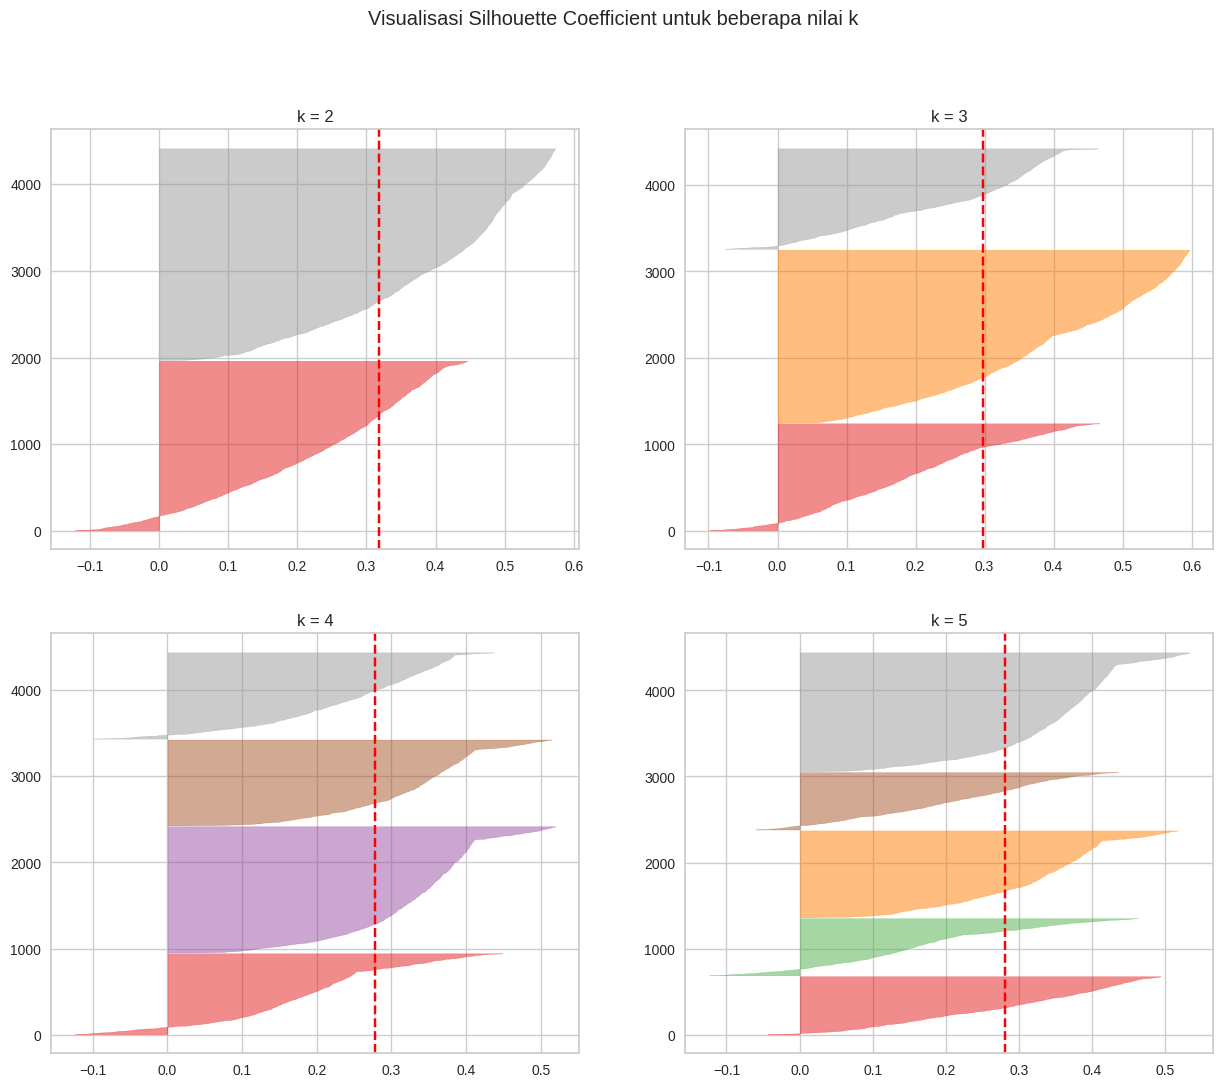

In [462]:
# Memvisualisasikan silhouette

fig, ax = plt.subplots(2, 2, figsize=(15,12))
fig.suptitle("Visualisasi Silhouette Coefficient untuk beberapa nilai k")
for k in [2, 3, 4, 5]:
    # Mendefinisikan model K-Means dengan nilai k tertentu
    clusterer = KMeans(n_clusters=k, n_init=10)

    # Memvisualisasikan densitas tiap klaster yang terbentuk
    q, mod = divmod(k, 2)
    ax[q-1][mod].set_title(f"k = {k}")
    visualizer = SilhouetteVisualizer(clusterer, ax = ax[q-1][mod])
    visualizer.fit(df_cluster_new)

##Train Model

In [463]:
# Latih model sesuai jumlah klaster optimal
kmeans = KMeans(n_clusters=2, n_init=10)
assignment = kmeans.fit_predict(df_cluster_new)

In [464]:
# Append hasil clustering ke dataframe
df_with_clusters = pd.DataFrame(df_cluster_new.copy())
df_with_clusters['cluster'] = assignment
df_with_clusters.head()

,act_total_km,act_avg_spd,user_age_group,cluster
0,-0.932674,-1.597743,2,1
1,-0.713738,-0.172076,2,1
2,0.050210,0.766338,2,0
3,1.475624,1.614519,2,0
5,0.787761,0.531734,0,0


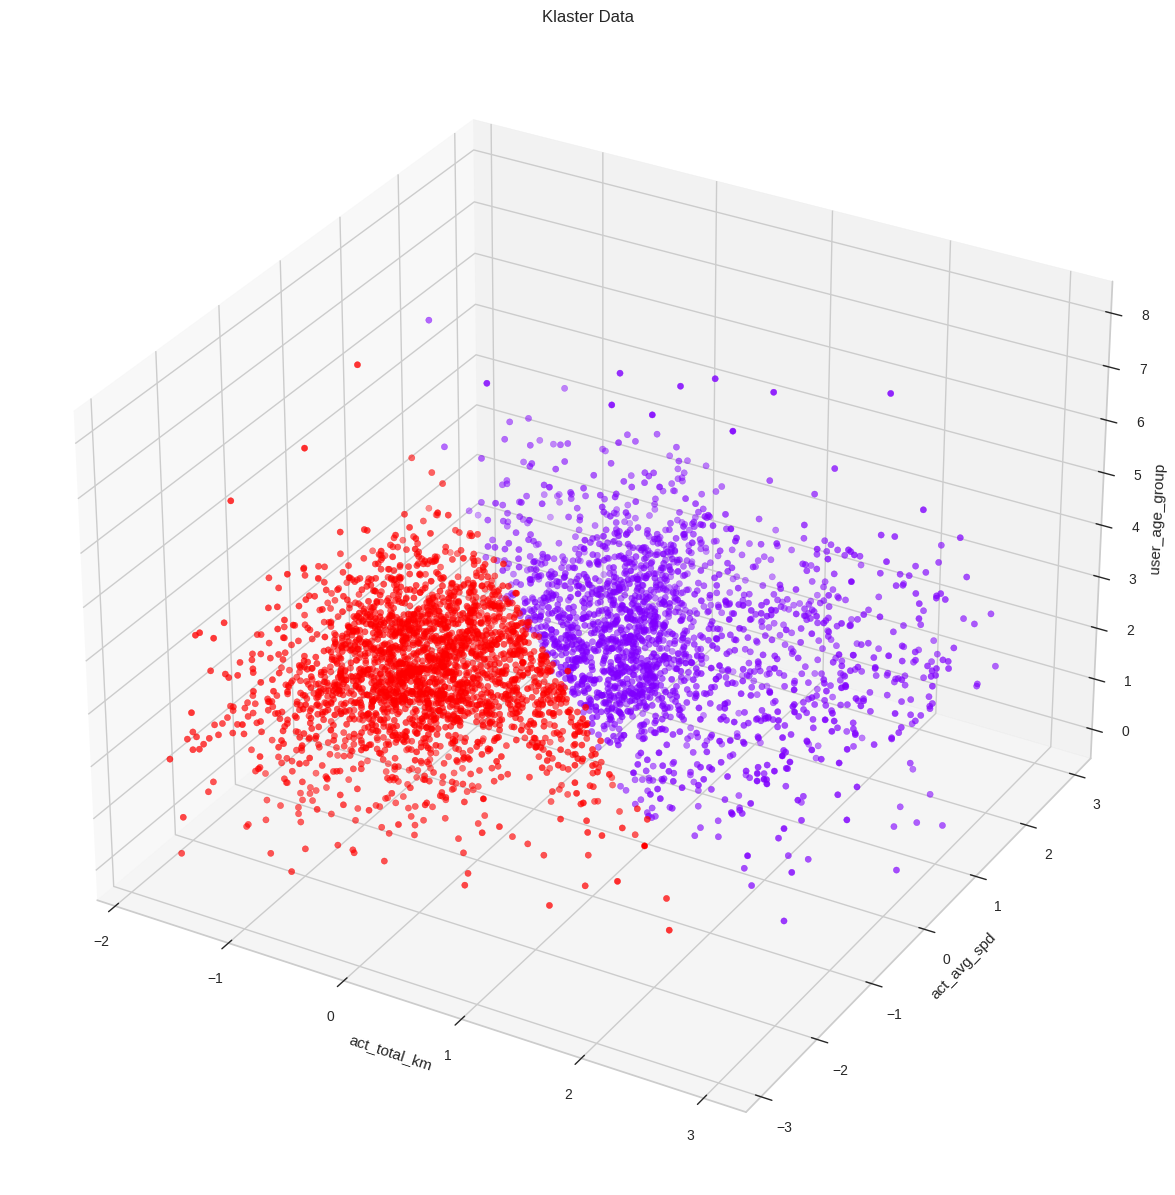

In [465]:
fig = plt.figure(figsize = (15, 15))
ax = plt.axes(projection="3d")

# Menyiapkan beberapa variabel yang diperlukan untuk visualisasi
x = df_with_clusters['act_total_km']
y = df_with_clusters['act_avg_spd']
z = df_with_clusters['user_age_group']
cluster = df_with_clusters['cluster']

# Memvisualisasikan hasilnya
ax.scatter(x, y, z, c = cluster, cmap = "rainbow")
plt.title("Klaster Data")
plt.grid(False)
ax.set_xlabel('act_total_km')
ax.set_ylabel('act_avg_spd')
ax.set_zlabel('user_age_group')

plt.show()